In [1]:
from skimage import morphology
import numpy as np
from skimage import io, data, transform, util, filters, color, exposure, restoration, measure, feature
import matplotlib.pyplot as plt
from skimage.util import img_as_float, img_as_float64, img_as_ubyte
from scipy import ndimage, fft
import math

In [2]:
def show(img_list, caption_list, Axis=False, rescale = True):
    n = len(img_list)
    f, ax = plt.subplots(1,n, figsize=(10+5*(n-1),10))
    for i in range(n):
        if rescale:
            ax[i].imshow(img_list[i], cmap='gray')
        else:
            ax[i].imshow(img_list[i], cmap='gray', vmin=0, vmax=255)
        ax[i].set_title(caption_list[i])
        if not Axis:
            ax[i].set_axis_off()

## Elementos estruturantes

1. **skimage.morphology.diamond**(radius). Generates a flat, diamond-shaped footprint. A pixel is part of the neighborhood (i.e. labeled 1) if the city block/Manhattan distance between it and the center of the neighborhood is no greater than radius.
    * radius: int. The radius of the diamond-shaped footprint.

    Returns
    * footprint: ndarray. The footprint where elements of the neighborhood are 1 and 0 otherwise.

2. **skimage.morphology.disk**(radius): Generates a flat, disk-shaped footprint. A pixel is within the neighborhood if the Euclidean distance between it and the origin is no greater than radius.
    * radius: int. The radius of the disk-shaped footprint.

    Returns
    * footprint: ndarray. The footprint where elements of the neighborhood are 1 and 0 otherwise.

3. **skimage.morphology.rectangle**(nrows, ncols). Generates a flat, rectangular-shaped footprint.
    * rows: int. The number of rows of the rectangle.
    * ncols: int. The number of columns of the rectangle.

    Returns
    * footprint: ndarray. A footprint consisting only of ones, i.e. every pixel belongs to the neighborhood.

4. **skimage.morphology.square**(width). Generates a flat, square-shaped footprint.
    * width: int. The width and height of the square.

    Returns
    * footprint: ndarray. A footprint consisting only of ones, i.e. every pixel belongs to the neighborhood.

In [3]:
disco = morphology.diamond(radius=3)
print('Diamond')
print(disco)
disco = morphology.disk(radius=3)
print('Disco')
print(disco)
disco = morphology.rectangle(nrows=4, ncols=6)
print('Rectangulo')
print(disco)
disco = morphology.square(width=5)
print('Quadrado')
print(disco)

Diamond
[[0 0 0 1 0 0 0]
 [0 0 1 1 1 0 0]
 [0 1 1 1 1 1 0]
 [1 1 1 1 1 1 1]
 [0 1 1 1 1 1 0]
 [0 0 1 1 1 0 0]
 [0 0 0 1 0 0 0]]
Disco
[[0 0 0 1 0 0 0]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [1 1 1 1 1 1 1]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [0 0 0 1 0 0 0]]
Rectangulo
[[1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]]
Quadrado
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


## Dilataçao

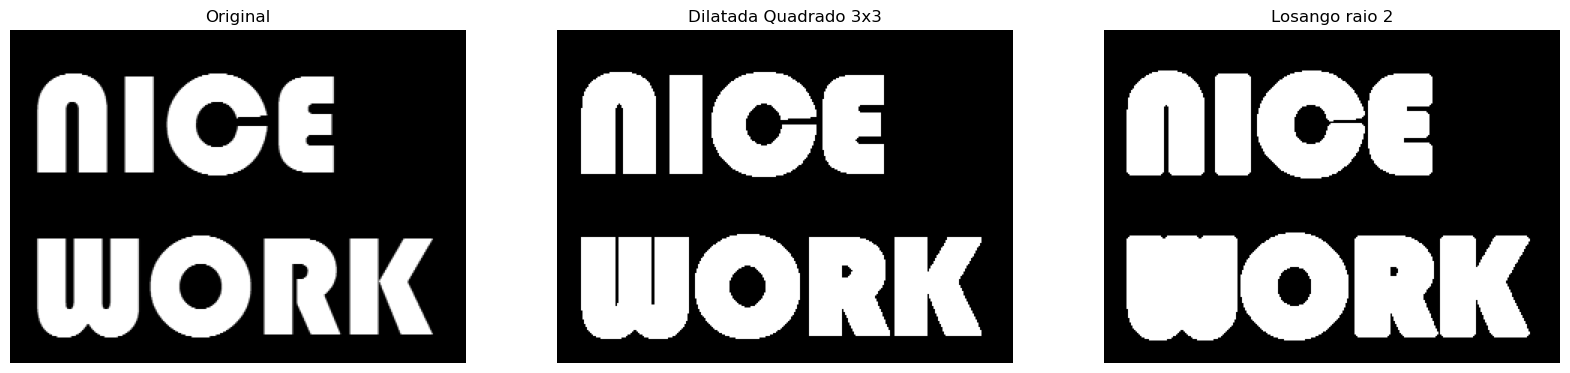

In [4]:
img = io.imread('D://Dropbox//UFOP//BCC326//test//png//letra.png')
img_dil = morphology.binary_dilation(img, np.ones((3,3)))
img_dil2 = morphology.binary_dilation(img, morphology.diamond(radius=2))
show([img, img_dil, img_dil2], ['Original','Dilatada Quadrado 3x3', 'Losango raio 2'])

## Erosão

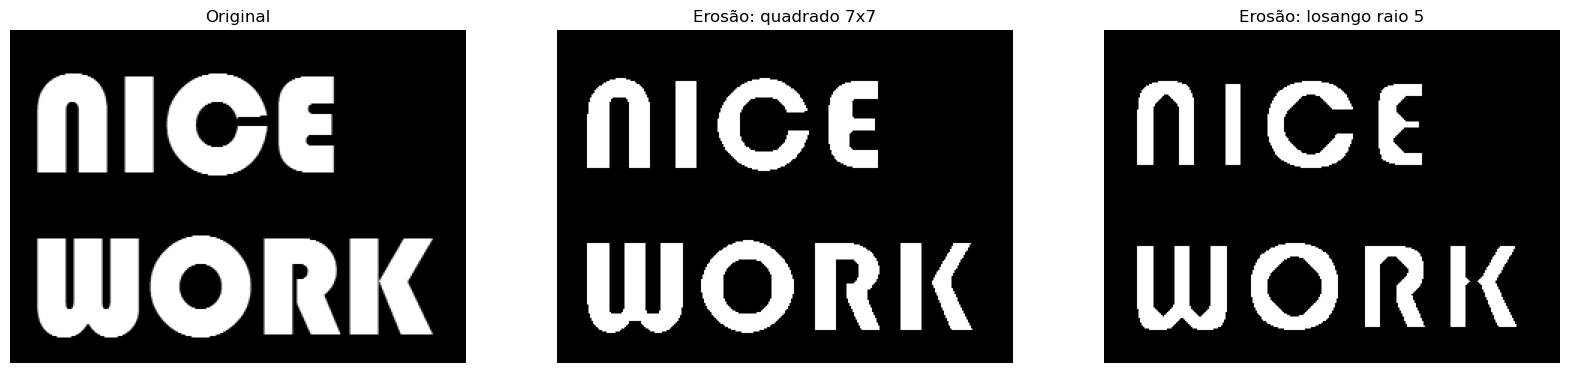

In [5]:
img_ero = morphology.binary_erosion(img, np.ones((7,7)))
img_ero2 = morphology.binary_erosion(img, morphology.diamond(radius=5))
show([img, img_ero, img_ero2], ['Original','Erosão: quadrado 7x7', 'Erosão: losango raio 5'])

## Abertura

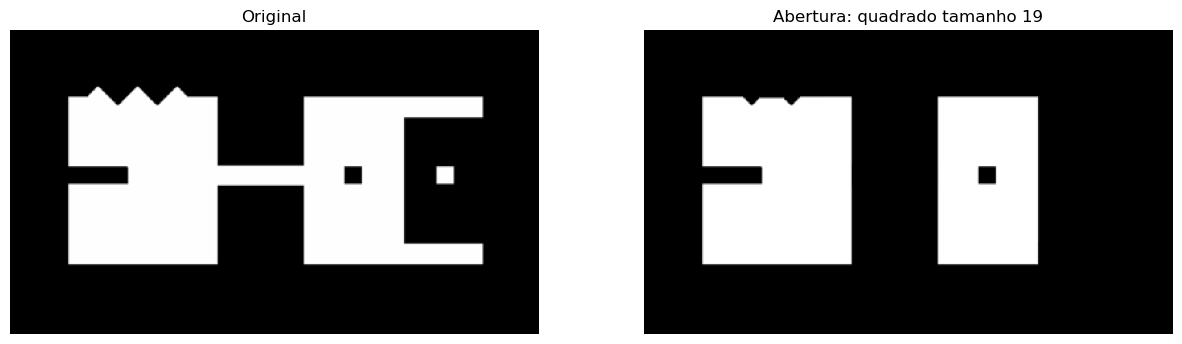

In [6]:
img = io.imread('D://Dropbox//UFOP//BCC326//test//png//morfologia.png', as_gray=True)
img_open = morphology.opening(img,  morphology.square(width=19))
show([img, img_open], ['Original','Abertura: quadrado tamanho 19'])

## Fecho

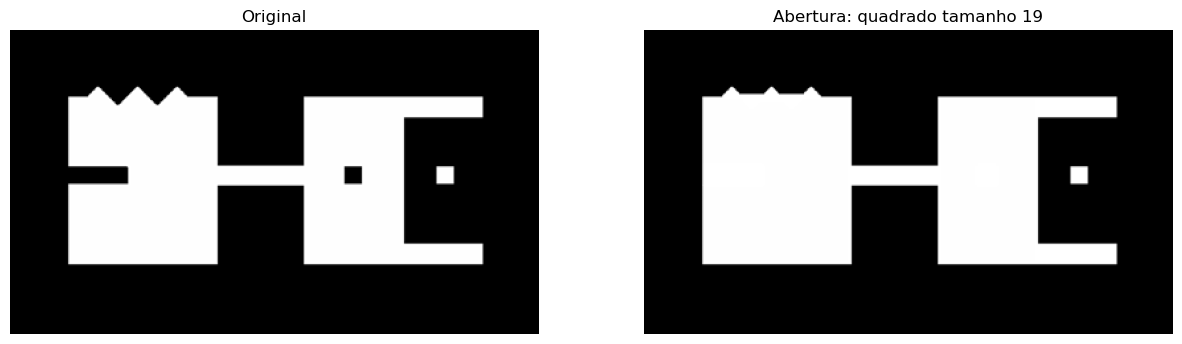

In [7]:
img = io.imread('D://Dropbox//UFOP//BCC326//test//png//morfologia.png', as_gray=True)
img_open = morphology.closing(img,  morphology.square(width=19))
show([img, img_open], ['Original','Abertura: quadrado tamanho 19'])

## Borda

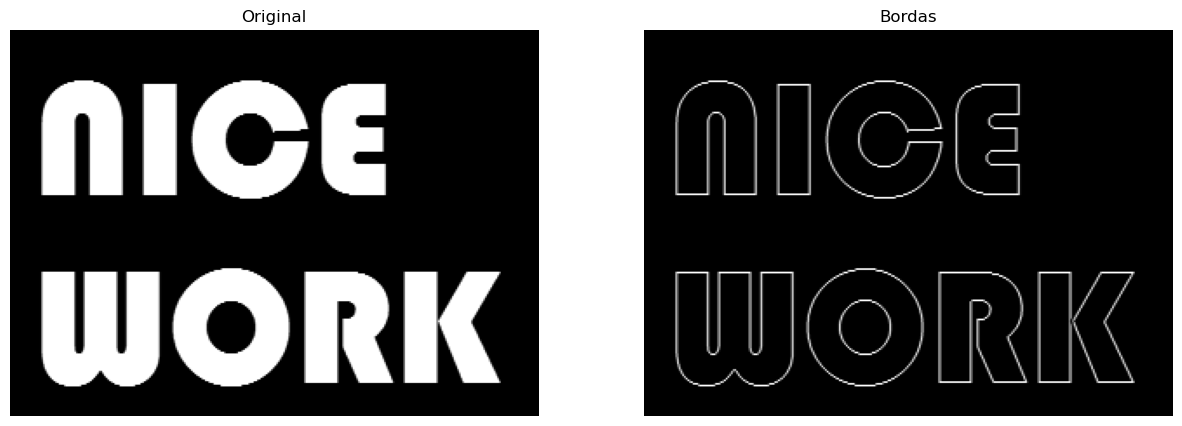

In [8]:
img = io.imread('D://Dropbox//UFOP//BCC326//test//png//letra.png', as_gray=True)
nimg = img - morphology.erosion(img, morphology.disk(radius=1))
show([img, nimg], ['Original','Bordas'])

## Preenchimento de região

In [10]:
def preenchimento(img, x, y):
    B = morphology.diamond(radius=1)
    X0 = np.zeros_like(img)
    X_old = np.zeros_like(img)
    X0[x,y] = 1
    while ( np.any( np.not_equal(X0, X_old) ) ):
        X_old = np.copy(X0)
        X0 = morphology.dilation(X0, B) * np.logical_not(img)
    return X0

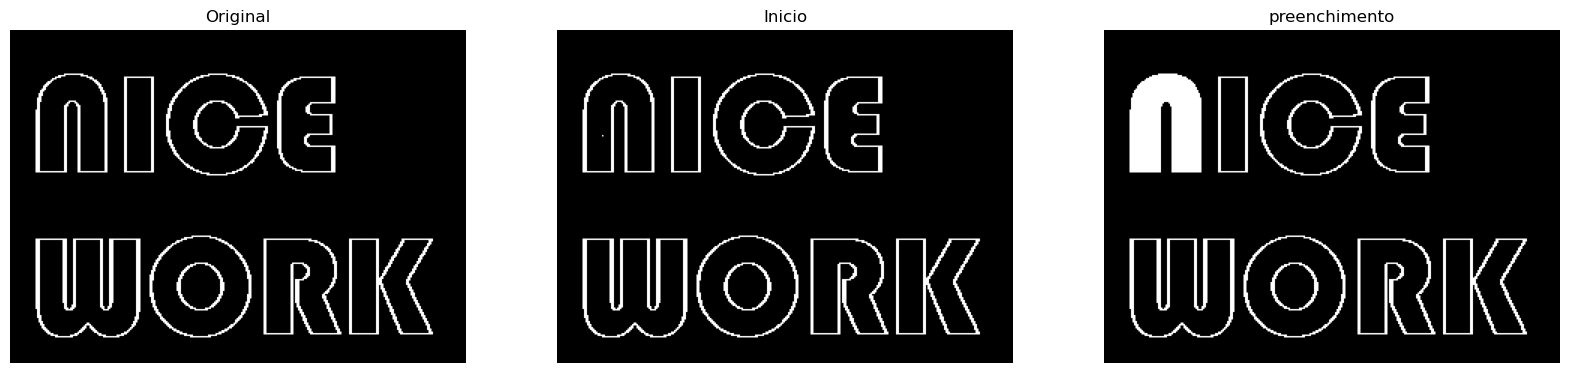

In [12]:
# coordenada dentro da letra N
x = 70
y = 30
#coordenada do fundo
#x = 7
#y = 3
img_p = preenchimento(nimg, x, y)
X0 = np.zeros_like(img)
X0[x,y] = 1
show([nimg>0.5, np.logical_or(nimg, X0), np.logical_or(img_p, nimg)], ['Original', 'Inicio', 'preenchimento'])

## Hit or Miss

In [13]:
a = np.zeros((7,7), dtype=int)
a[0, 1] = 1; a[1:3, 2:4] = 1; a[4:6, 4:6] = 1
print(a)
structure1 = np.array([[1, 1], [1, 1]])
structure2 = np.array([[1,1,1,1],[1,0,0,1], [1,0, 0,1],[1,1,1,1]])
print(structure1)
print(structure2)

# Find the matches of structure1 in the array a
ndimage.binary_hit_or_miss(a, structure1=structure1, structure2=structure2).astype(int)

[[0 1 0 0 0 0 0]
 [0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0]
 [0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0]]
[[1 1]
 [1 1]]
[[1 1 1 1]
 [1 0 0 1]
 [1 0 0 1]
 [1 1 1 1]]


array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0]])

## Skeletonization

In [14]:
def imskel(img, se=None):
    if se is None:
        se = morphology.diamond(radius=1)
    skel = np.zeros_like(img)
    erode = img
    while ( np.any(erode) ):
        open = morphology.opening( erode, se)
        skel = np.logical_or( skel, ( np.logical_and(erode, np.logical_not(open)) ) )
        erode = morphology.erosion( erode, se)
    return skel
    


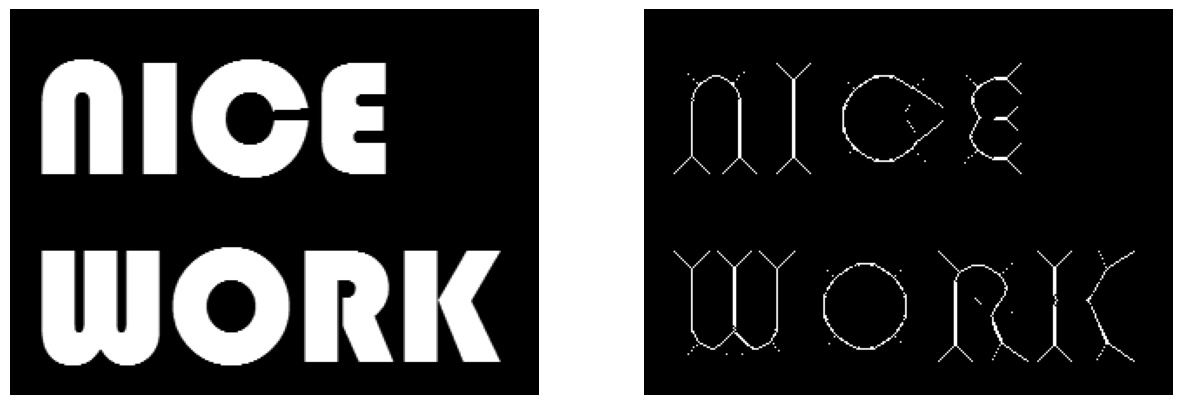

In [15]:
img = io.imread('D://Dropbox//UFOP//BCC326//test//png//letra.png', as_gray=True)
skel = imskel(img)
show([img, skel],["",""])

<p>
<b>skimage.morphology.skeletonize</b>(image, *, method=None): Compute the skeleton of a binary image.

Thinning is used to reduce each connected component in a binary image to a single-pixel wide skeleton.

Parameters:
image: ndarray, 2D or 3D. An image containing the objects to be skeletonized. Zeros represent background, nonzero values are foreground.
method: {‘zhang’, ‘lee’}, optional. Which algorithm to use. Zhang’s algorithm [Zha84] only works for 2D images, and is the default for 2D. Lee’s algorithm [Lee94] works for 2D or 3D images and is the default for 3D.

Returns:
skeleton: ndarray. The thinned image.
</p>

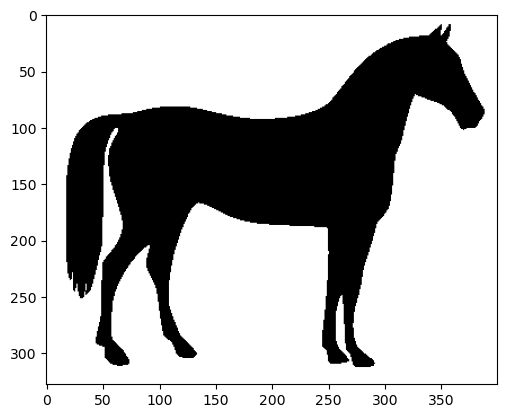

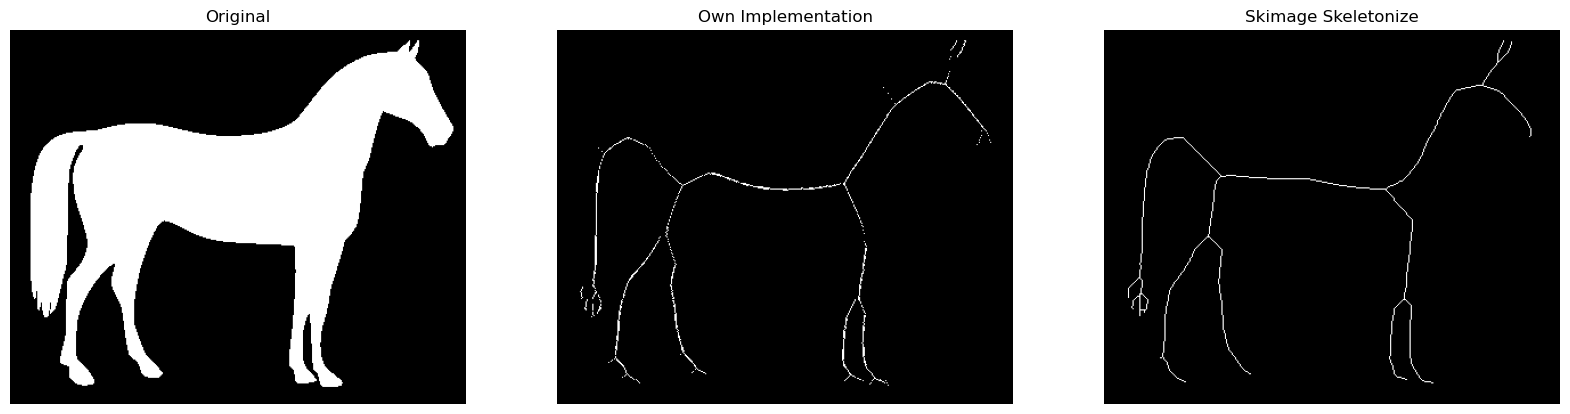

In [16]:
horse = data.horse()
plt.imshow(horse, cmap='gray')
horse = util.invert(horse)

skelHorse = imskel(horse)
skelHorse2 = morphology.skeletonize(horse)

show([horse, skelHorse, skelHorse2], ['Original', 'Own Implementation', 'Skimage Skeletonize'])